In [1]:
import cfg
from libs.data_request import DataRequest
from libs.analysis import PSDHistogram

import redis
import matplotlib.pyplot as plt

log = cfg.set_logger()
dr = DataRequest(log=log, base_url=cfg.API_URL)
r = redis.Redis()

camp_ids = {'10K': 189, '30K': 190, '100K': 191, '3K': 193}
target_nodes = [1,3,4,5,9]

[IPYKERNEL_LAUNCHER]INFO      Starting ANE2-Calibration-SDR v0.1.0 in America/Bogota...


[IPYKERNEL_LAUNCHER]INFO      Initialized DataRequest class with base_url: https://rsm.ane.gov.co:12443/api


In [2]:
df_full_rb = dr.load_campaigns_and_nodes(campaigns=camp_ids, node_ids=target_nodes)

[IPYKERNEL_LAUNCHER]INFO      Loading data for campaigns: ['10K', '30K', '100K', '3K'] and nodes: [1, 3, 4, 5, 9]

🚀 Starting Campaign: 10K
  ↳ Node 1 loaded instantly from RAM (Redis)
  ↳ Node 3 loaded instantly from RAM (Redis)
  ↳ Node 4 loaded instantly from RAM (Redis)
  ↳ Node 5 loaded instantly from RAM (Redis)
  ↳ Node 9 loaded instantly from RAM (Redis)

🚀 Starting Campaign: 30K
  ↳ Node 1 loaded instantly from RAM (Redis)
  ↳ Node 3 loaded instantly from RAM (Redis)
  ↳ Node 4 loaded instantly from RAM (Redis)
  ↳ Node 5 loaded instantly from RAM (Redis)
  ↳ Node 9 loaded instantly from RAM (Redis)

🚀 Starting Campaign: 100K
  ↳ Node 1 loaded instantly from RAM (Redis)
  ↳ Node 3 loaded instantly from RAM (Redis)
  ↳ Node 4 loaded instantly from RAM (Redis)
  ↳ Node 5 loaded instantly from RAM (Redis)
  ↳ Node 9 loaded instantly from RAM (Redis)

🚀 Starting Campaign: 3K
  ↳ Node 1 loaded instantly from RAM (Redis)
  ↳ Node 3 loaded instantly from RAM (Redis)
  ↳ Node 4 loaded

Computing data for all campaigns...
  -> 10K
  -> 30K
  -> 100K
  -> 3K


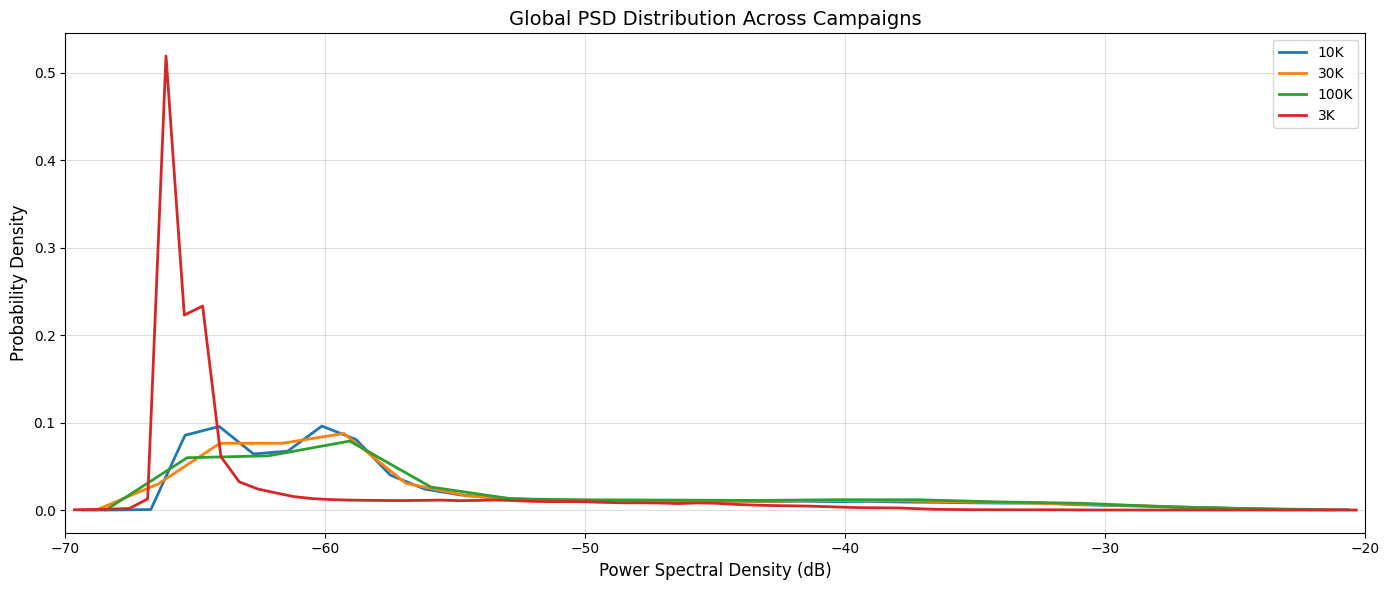

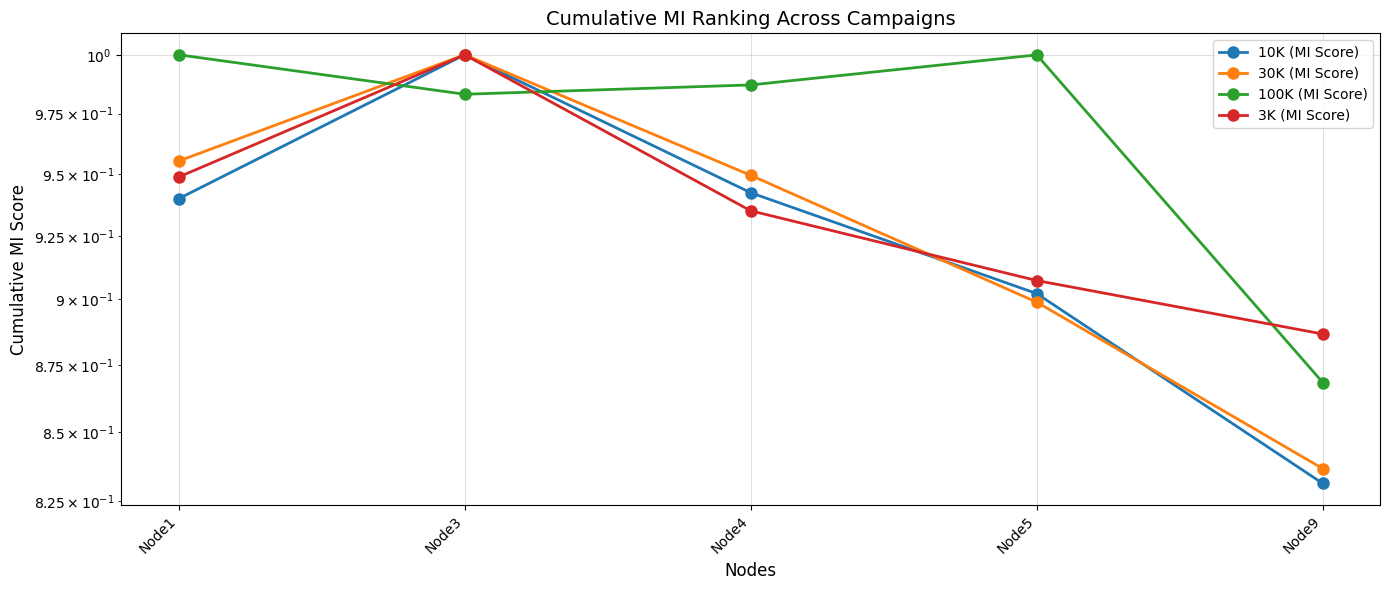

In [3]:
import matplotlib.pyplot as plt

# 1. Initialize and compute all analyzers first
analyzers = {}
print("Computing data for all campaigns...")
for camp_name in camp_ids.keys():
    print(f"  -> {camp_name}")
    analyzer = PSDHistogram(df_full_rb[camp_name], global_range=(-70, -20))
    analyzer.execute()
    analyzers[camp_name] = analyzer

# 2. Histogram Plot
plt.figure(figsize=(14, 6))

for camp_name, analyzer in analyzers.items():
    analyzer.plot_hist(label=camp_name, linewidth=2)

plt.xlabel('Power Spectral Density (dB)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Global PSD Distribution Across Campaigns', fontsize=14)
plt.xlim(-70, -20)
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Cumulative MI Plot
plt.figure(figsize=(14, 6))

for camp_name, analyzer in analyzers.items():
    analyzer.plot_mi(label=f"{camp_name} (MI Score)", linewidth=2, markersize=8)

plt.xlabel('Nodes', fontsize=12)
plt.ylabel('Cumulative MI Score', fontsize=12)
plt.title('Cumulative MI Ranking Across Campaigns', fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()